<a href="https://colab.research.google.com/github/davifriggiunifesp/evasao-escolar-xgboost-mlp/blob/main/codigos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# baixa a base id=697
dados = fetch_ucirepo(id=697)

X = dados.data.features
y = dados.data.targets # Dropout / Enrolled / Graduate

print(X.shape) # linhas, colunas
X.head() # primeiras linhas

(4424, 36)


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


In [ ]:
import pandas as pd

df = pd.concat([X, y], axis=1)

print(df.shape) # linhas, colunas
print("\nvazios:", df.isnull().sum().sum()) # valores vazios
print("\ncolunas:")
print(df.dtypes.value_counts())
df.head()

(4424, 37)

vazios: 0

colunas:
int64      29
float64     7
object      1
Name: count, dtype: int64


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


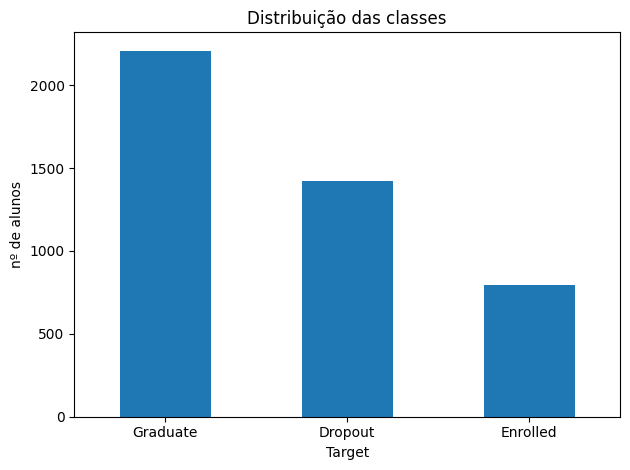

In [ ]:
import matplotlib.pyplot as plt

alvo = y.columns[0]

# contagem e proporção de cada categoria
print(df[alvo].value_counts())
print(df[alvo].value_counts(normalize=True).round(3))

# gráfico de barras
df[alvo].value_counts().plot(kind='bar')
plt.title('Distribuição das classes')
plt.ylabel('nº de alunos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# categoria -> número
le = LabelEncoder()
y_enc = le.fit_transform(y.values.ravel())
print("Mapeamento:", list(le.classes_))

# treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc # stratify=y_enc mantém a estratificação existente na base de dados
)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

# padronização das escalas necessária para MLP, pois é sensível a escala das variáveis de entrada
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # aprende média/desvio - treino
X_test_scaled  = scaler.transform(X_test)        # aplica o mesmo ao teste

Mapeamento: ['Dropout', 'Enrolled', 'Graduate']
Treino: (3539, 36) | Teste: (885, 36)


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time

# XGBoost
modelo_xgb = XGBClassifier(
    n_estimators=300,      # numero de árvores
    max_depth=6,           # profundidade de cada árvore
    learning_rate=0.1,     # correção
    random_state=42
)

# treino
inicio = time.time()
modelo_xgb.fit(X_train, y_train)
tempo_treino = time.time() - inicio

# teste
y_pred = modelo_xgb.predict(X_test)

# desempenho
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"Tempo de treino: {tempo_treino:.2f}s")
print(f"Acurácia: {acc:.3f}")
print(f"F1-macro: {f1_macro:.3f}\n")
print(classification_report(y_test, y_pred,
      target_names=['Dropout', 'Enrolled', 'Graduate']))

Tempo de treino: 1.43s
Acurácia: 0.767
F1-macro: 0.704

              precision    recall  f1-score   support

     Dropout       0.79      0.74      0.76       284
    Enrolled       0.52      0.46      0.49       159
    Graduate       0.83      0.90      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.76      0.77      0.76       885



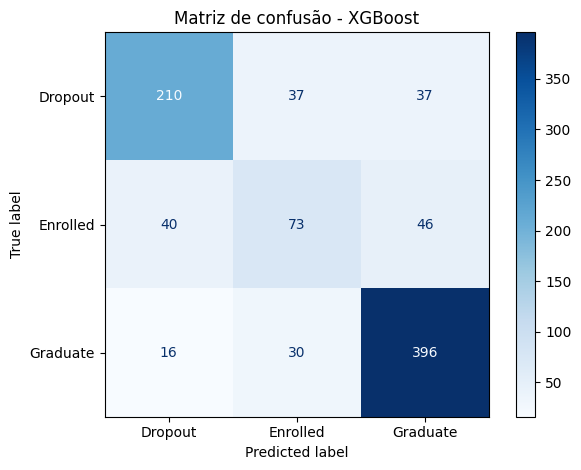

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# matriz de confusão XGBoost
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dropout', 'Enrolled', 'Graduate'])
disp.plot(cmap='Blues')
plt.title('Matriz de confusão - XGBoost')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time


modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32), # a primeira camada com 64 neurônios, segunda camada com 32 neurônios
    activation='relu', # função de ativação Rectified Linear Unit
    max_iter=500, # nº máximo de iterações
    random_state=42
)

inicio = time.time()
modelo_mlp.fit(X_train_scaled, y_train)   # X_train_scaled porque esta padrozinado
tempo_treino = time.time() - inicio

y_pred_mlp = modelo_mlp.predict(X_test_scaled)   # teste também padronizado

acc = accuracy_score(y_test, y_pred_mlp)
f1_macro = f1_score(y_test, y_pred_mlp, average='macro')

print(f"Tempo de treino: {tempo_treino:.2f}s")
print(f"Acurácia: {acc:.3f}")
print(f"F1-macro: {f1_macro:.3f}\n")
print(classification_report(y_test, y_pred_mlp,
      target_names=['Dropout', 'Enrolled', 'Graduate']))

Tempo de treino: 12.79s
Acurácia: 0.670
F1-macro: 0.622

              precision    recall  f1-score   support

     Dropout       0.70      0.69      0.70       284
    Enrolled       0.36      0.46      0.40       159
    Graduate       0.81      0.73      0.77       442

    accuracy                           0.67       885
   macro avg       0.62      0.63      0.62       885
weighted avg       0.69      0.67      0.68       885



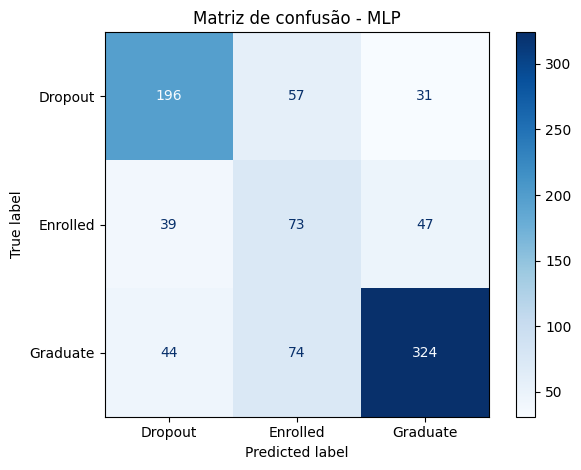

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# matriz de confusão MLP
cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dropout', 'Enrolled', 'Graduate'])
disp.plot(cmap='Blues')
plt.title('Matriz de confusão - MLP')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np, time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

xgb_f1, mlp_f1 = [], []
xgb_time, mlp_time = [], []
inicio = time.time()

for seed in range(30):
    # te = teste, tr = treino
    X_tr, X_te, y_tr, y_te = train_test_split(X, y_enc, test_size=0.2, random_state=seed, stratify=y_enc)

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr) # fit só no treino
    X_te_s = scaler.transform(X_te)

    xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=seed)
    inicio_xgb = time.time()
    xgb.fit(X_tr, y_tr) # XGBoost
    treino_xgb = time.time() - inicio_xgb
    xgb_time.append(treino_xgb)
    xgb_f1.append(f1_score(y_te, xgb.predict(X_te), average='macro'))

    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=seed)
    inicio_mlp = time.time()
    mlp.fit(X_tr_s, y_tr) # MLP
    treino_mlp = time.time() - inicio_mlp
    mlp_time.append(treino_mlp)
    mlp_f1.append(f1_score(y_te, mlp.predict(X_te_s), average='macro'))

    print(f"Execução {seed+1:2d}/30 -> XGB {xgb_f1[-1]:.3f} Tempo {treino_xgb:.1f}s | MLP {mlp_f1[-1]:.3f} Tempo {treino_mlp:.1f}s")

xgb_f1, mlp_f1 = np.array(xgb_f1), np.array(mlp_f1)
xgb_time, mlp_time = np.array(xgb_time), np.array(mlp_time) # média dos tempos

print(f"\nTempo total: {time.time()-inicio:.1f}s")
print(f"\nTempo médio XGBoost: {xgb_time.mean():.1f}s")
print(f"\nTempo médio MLP: {mlp_time.mean():.1f}s")
print(f"XGBoost F1-macro: {xgb_f1.mean():.3f} ± {xgb_f1.std(ddof=1):.3f}")
print(f"MLP     F1-macro: {mlp_f1.mean():.3f} ± {mlp_f1.std(ddof=1):.3f}")

Execução  1/30 -> XGB 0.723 Tempo 6.9s | MLP 0.636 Tempo 8.7s
Execução  2/30 -> XGB 0.703 Tempo 1.5s | MLP 0.672 Tempo 7.7s
Execução  3/30 -> XGB 0.725 Tempo 3.8s | MLP 0.652 Tempo 9.2s
Execução  4/30 -> XGB 0.729 Tempo 3.7s | MLP 0.636 Tempo 9.4s
Execução  5/30 -> XGB 0.713 Tempo 3.9s | MLP 0.644 Tempo 8.4s
Execução  6/30 -> XGB 0.703 Tempo 3.1s | MLP 0.656 Tempo 8.8s
Execução  7/30 -> XGB 0.697 Tempo 1.5s | MLP 0.627 Tempo 9.8s
Execução  8/30 -> XGB 0.724 Tempo 1.5s | MLP 0.650 Tempo 9.3s
Execução  9/30 -> XGB 0.680 Tempo 1.5s | MLP 0.598 Tempo 11.1s
Execução 10/30 -> XGB 0.699 Tempo 1.5s | MLP 0.650 Tempo 10.9s
Execução 11/30 -> XGB 0.704 Tempo 1.4s | MLP 0.632 Tempo 9.8s
Execução 12/30 -> XGB 0.727 Tempo 1.7s | MLP 0.635 Tempo 6.7s
Execução 13/30 -> XGB 0.729 Tempo 1.4s | MLP 0.682 Tempo 9.8s
Execução 14/30 -> XGB 0.726 Tempo 1.5s | MLP 0.655 Tempo 9.2s
Execução 15/30 -> XGB 0.680 Tempo 1.5s | MLP 0.615 Tempo 10.7s
Execução 16/30 -> XGB 0.701 Tempo 1.4s | MLP 0.623 Tempo 9.3s
Execu

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


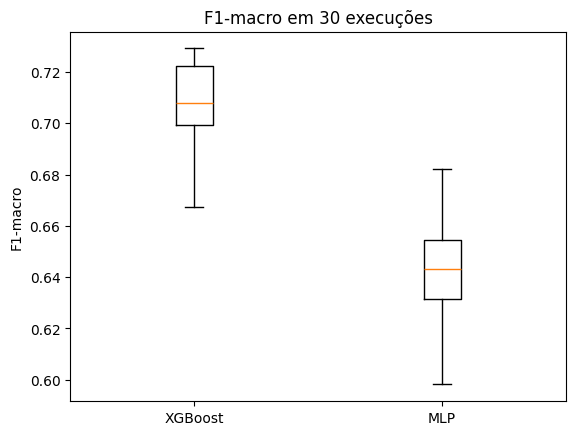

In [ ]:
from scipy import stats
import matplotlib.pyplot as plt

# boxplot
plt.boxplot([xgb_f1, mlp_f1])
plt.xticks([1, 2], ['XGBoost', 'MLP'])
plt.ylabel('F1-macro')
plt.title('F1-macro em 30 execuções')
plt.show()

max_depth=2: F1=0.712 | tempo=0.34s
max_depth=4: F1=0.718 | tempo=0.54s
max_depth=6: F1=0.718 | tempo=0.95s
max_depth=8: F1=0.720 | tempo=1.62s
max_depth=10: F1=0.713 | tempo=1.95s
max_depth=12: F1=0.710 | tempo=2.05s


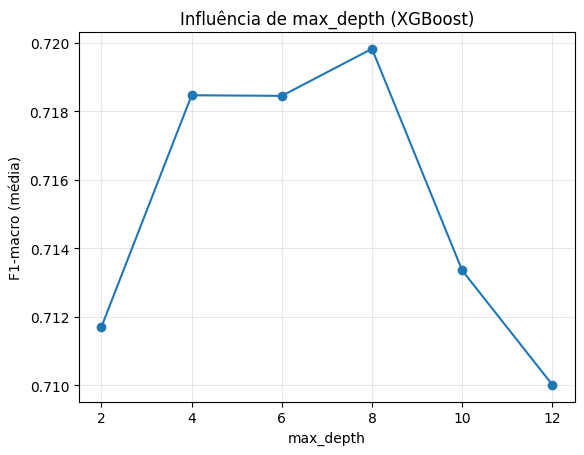

n_estimators=50: F1=0.716 | tempo=0.20s
n_estimators=100: F1=0.725 | tempo=0.35s
n_estimators=200: F1=0.723 | tempo=0.64s
n_estimators=300: F1=0.718 | tempo=1.16s
n_estimators=500: F1=0.714 | tempo=1.69s


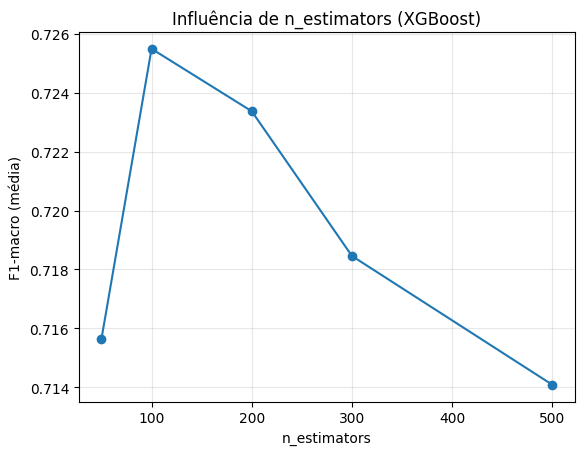

learning_rate=0.01: F1=0.711 | tempo=1.18s
learning_rate=0.05: F1=0.725 | tempo=1.18s
learning_rate=0.1: F1=0.718 | tempo=0.92s
learning_rate=0.3: F1=0.705 | tempo=0.91s


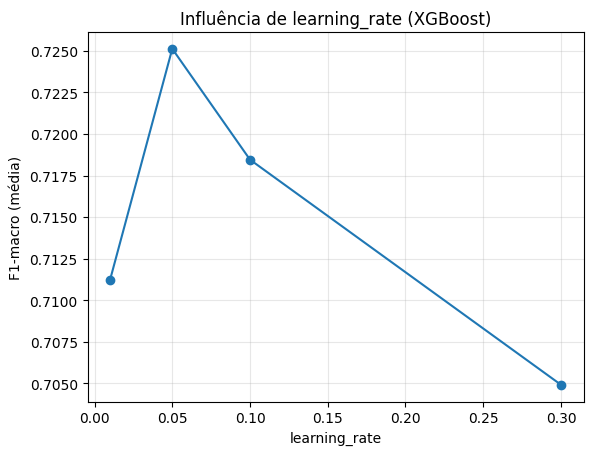

([np.float64(0.7112253554956631),
  np.float64(0.72513078521274),
  np.float64(0.7184568171339683),
  np.float64(0.7049073410490126)],
 [np.float64(1.1752393245697021),
  np.float64(1.1820856571197509),
  np.float64(0.9243741035461426),
  np.float64(0.9073047637939453)])

In [ ]:
import numpy as np, time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

def varia_xgb(nome_param, valores, n_seeds=5):
    f1_medio, tempo_medio = [], []
    for v in valores:
        f1s, tempos = [], []
        for seed in range(n_seeds):
            X_tr, X_te, y_tr, y_te = train_test_split(X, y_enc, test_size=0.2, random_state=seed, stratify=y_enc)
            params = {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'random_state': seed}
            params[nome_param] = v  # sobrescrevendo somente o parâmetro alvo
            modelo = XGBClassifier(**params)
            inicio = time.time()
            modelo.fit(X_tr, y_tr)
            tempos.append(time.time() - inicio)
            f1s.append(f1_score(y_te, modelo.predict(X_te), average='macro'))
        f1_medio.append(np.mean(f1s)); tempo_medio.append(np.mean(tempos))
        print(f"{nome_param}={v}: F1={np.mean(f1s):.3f} | tempo={np.mean(tempos):.2f}s")
    # gráficos
    plt.plot(valores, f1_medio, marker='o')
    plt.xlabel(nome_param); plt.ylabel('F1-macro (média)')
    plt.title(f'Influência de {nome_param} (XGBoost)')
    plt.grid(True, alpha=0.3); plt.show()
    return f1_medio, tempo_medio

# variando primeiro profundidades
varia_xgb('max_depth', [2, 4, 6, 8, 10, 12])
# variando estimadores
varia_xgb('n_estimators', [50, 100, 200, 300, 500])
# variando passo
varia_xgb('learning_rate', [0.01, 0.05, 0.1, 0.3])


hidden_layer_sizes=(32,): F1=0.678 | tempo=3.57s
hidden_layer_sizes=(64,): F1=0.660 | tempo=4.85s
hidden_layer_sizes=(64, 32): F1=0.653 | tempo=5.19s
hidden_layer_sizes=(128, 64): F1=0.646 | tempo=6.73s
hidden_layer_sizes=(128, 64, 32): F1=0.654 | tempo=4.75s


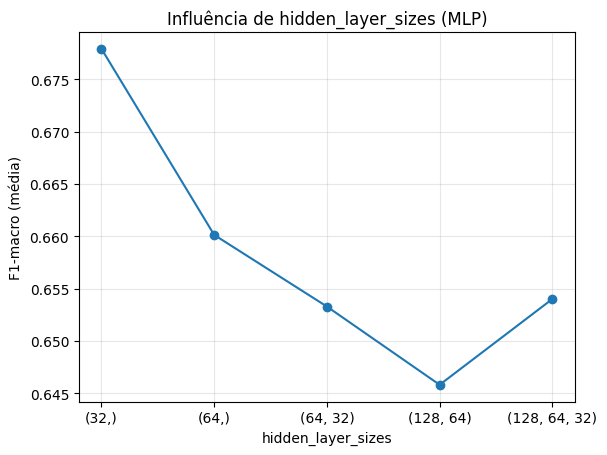

max_iter=300: F1=0.653 | tempo=3.99s
max_iter=500: F1=0.653 | tempo=5.18s
max_iter=1000: F1=0.653 | tempo=5.44s
max_iter=2000: F1=0.653 | tempo=5.41s


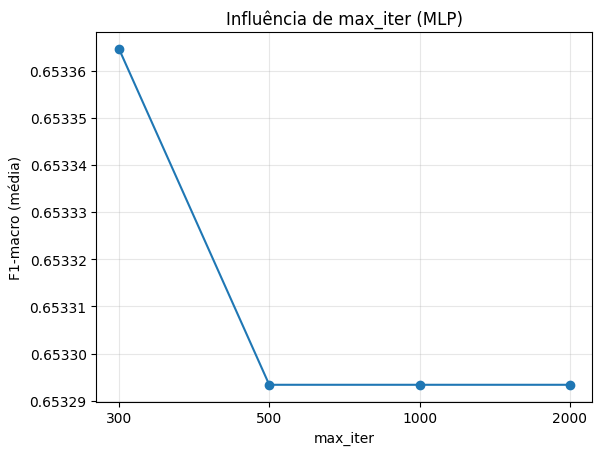

([np.float64(0.6533646367782174),
  np.float64(0.6532933867474396),
  np.float64(0.6532933867474396),
  np.float64(0.6532933867474396)],
 [np.float64(3.987528642018636),
  np.float64(5.184060732523601),
  np.float64(5.440807660420735),
  np.float64(5.407429218292236)])

In [ ]:
import numpy as np, time, warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning

def varia_mlp(nome_param, valores, n_seeds=3):
    f1_medio, tempo_medio = [], []
    for v in valores:
        f1s, tempos = [], []
        for seed in range(n_seeds):
            X_tr, X_te, y_tr, y_te = train_test_split(X, y_enc, test_size=0.2, random_state=seed, stratify=y_enc)
            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)    # tranformação dos dados para a MLP
            X_te_s = scaler.transform(X_te)
            params = {'hidden_layer_sizes': (64, 32), 'activation': 'relu', 'max_iter': 500, 'random_state': seed}
            params[nome_param] = v                 # sobrescrevendo somente o parâmetro alvo
            modelo = MLPClassifier(**params)
            with warnings.catch_warnings():        # aviso de convergência
                warnings.simplefilter('ignore', ConvergenceWarning)
                inicio = time.time()
                modelo.fit(X_tr_s, y_tr)
                tempos.append(time.time() - inicio)
            f1s.append(f1_score(y_te, modelo.predict(X_te_s), average='macro'))
        f1_medio.append(np.mean(f1s)); tempo_medio.append(np.mean(tempos))
        print(f"{nome_param}={v}: F1={np.mean(f1s):.3f} | tempo={np.mean(tempos):.2f}s")
    # graficos
    x = range(len(valores))
    plt.plot(x, f1_medio, marker='o')
    plt.xticks(x, [str(v) for v in valores])
    plt.xlabel(nome_param); plt.ylabel('F1-macro (média)')
    plt.title(f'Influência de {nome_param} (MLP)')
    plt.grid(True, alpha=0.3); plt.show()
    return f1_medio, tempo_medio

# variando tamanho da rede
varia_mlp('hidden_layer_sizes', [(32,), (64,), (64, 32), (128, 64), (128, 64, 32)])
# variando iterações
varia_mlp('max_iter', [300, 500, 1000, 2000])


In [ ]:
!pip freeze

absl-py==1.4.0
accelerate==1.14.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.2
aiohttp==3.14.1
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.0
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.2.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.6.8.17.49.5
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.7.2
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.42.0
bigquery-magics==0.14.0
bleach==6.4.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.4.5
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.47
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.5.20
cf

In [ ]:
import platform, multiprocessing
# CPU
!cat /proc/cpuinfo | grep "model name" | head -1
print("Núcleos:", multiprocessing.cpu_count())
print("Python:", platform.python_version())

model name	: AMD EPYC 7B12
Núcleos: 2
Python: 3.12.13
